# Regresión logística binomial (Parte 1)


A lo largo de los siguientes ejercicios, aprenderás a usar Python para construir y evaluar un modelo de regresión logística binomial. Antes de comenzar con este ejercicio de programación, te recomendamos encarecidamente ver la conferencia en video y completar la IVQ para los temas asociados.


Toda la información que necesitas para resolver esta tarea está en este cuaderno, y todo el código que implementarás tendrá lugar dentro de este cuaderno.


A medida que avanzamos, puedes encontrar instrucciones sobre cómo instalar las bibliotecas requeridas a medida que surjan en este cuaderno. Antes de comenzar con los ejercicios y analizar los datos, necesitamos importar todas las bibliotecas y extensiones requeridas para este ejercicio de programación. A lo largo del curso, utilizaremos pandas y sickit-learn para operaciones, y seaborn para graficar.


## Importaciones relevantes


Comience importando los paquetes y datos relevantes.


In [1]:
# Import pandas and seaborn packages
import pandas as pd
import seaborn as sns

## Análisis exploratorio de datos


**Nota:** La siguiente celda de código se muestra en el video, pero solo funcionará si el archivo .csv está en la misma carpeta que el cuaderno. De lo contrario, por favor siga el proceso de carga de datos descrito arriba.


In [2]:
# Load in if csv file is in the same folder as notebook
activity = pd.read_csv("activity.csv")

In [3]:
# Get summary statistics about the dataset
activity.describe()

,Acc (vertical),LyingDown
count,494.000000,494.000000
mean,45.512363,0.516194
std,44.799360,0.500244
min,-48.459000,0.000000
25%,0.918650,0.000000
50%,41.109500,1.000000
75%,89.339000,1.000000
max,112.310000,1.000000


In [4]:
# Examine the dataset
activity.head()

,Acc (vertical),LyingDown
0,96.229,0
1,84.746,0
2,82.449,0
3,106.560,0
4,80.152,0


## Construir modelo de regresión logística binomial


Para regresión logística binomial, usaremos el paquete `scikit-learn`, que se usa con frecuencia para aprendizaje automático y temas más avanzados de ciencia de datos. Para los propósitos de este ejercicio, solo cargaremos las funciones que necesitamos: `train_test_split()` y `LogisticRegression()`.


In [5]:
# Load in sci-kit learn functions for constructing logistic regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Luego, guardaremos los datos en variables llamadas X y y para que podamos usar la función `train_test_split()` con mayor facilidad. Recuerda que puedes subconjuntar columnas específicas de un objeto DataFrame usando doble corchete: `[[]]` y listando las columnas entre ellos, separadas por comas.


In [6]:
# Save X and y data into variables
X = activity[["Acc (vertical)"]]
y = activity[["LyingDown"]]

Luego dividiremos los datos en conjuntos de entrenamiento y de reserva. Establecemos el `test_size` en `0.3` para que el conjunto de reserva sea solo el 30% del total de datos que tenemos. Estableceremos el `random_state` igual a `42`. Si cambias esta variable, tus resultados serán diferentes a los nuestros. Establecer el `random_state` es principalmente para fines de reproducibilidad.


In [7]:
# Split dataset into training and holdout datasets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

Luego construiremos nuestro clasificador, y ajustaremos el modelo a los datos usando la función `.fit()`. Guardaremos el modelo ajustado como una variable llamada `clf`.


In [10]:
import numpy as np

In [11]:
clf = LogisticRegression().fit(X_train,np.ravel(y_train))

## Obtener coeficientes y visualizar modelo


Podemos usar los atributos `coef_` e `intercept_` del objeto `clf` para obtener el coeficiente y la intersección de nuestro modelo.


In [12]:
# Print the coefficient
clf.coef_

array([[-0.1177471]])

In [13]:
# Print the intercept
clf.intercept_

array([6.10180958])

Entonces, basado en lo que hemos encontrado, nuestro modelo tiene un intercepto o $\beta_0$ de 6.10 y un $\beta_1$ de -0.12. Ahora podemos graficar nuestro modelo y datos con una banda de confianza del 95% usando la función `regplot()` del paquete `seaborn`. Recuerda establecer el argumento `logistic=True` para que la función sepa que estamos graficando un modelo de regresión logística, no un modelo de regresión lineal.


<Axes: xlabel='Acc (vertical)', ylabel='LyingDown'>

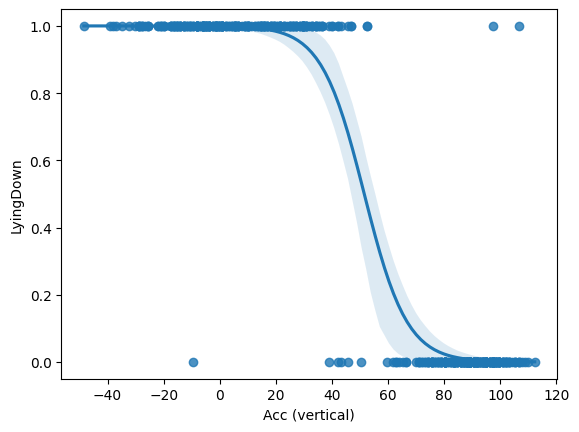

In [14]:
# Plot the logistic regression and its confidence band
sns.regplot(x="Acc (vertical)", y="LyingDown", data=activity, logistic=True)

# Matriz de confusión (Parte II)


Esta parte del cuaderno contiene todo el código que se presentará en la segunda parte de esta sección en el curso. El enfoque está en **matrices de confusión**, que se utilizan para evaluar modelos de clasificación, como un modelo de regresión logística binomial.

**Nota:** Suponemos que las partes anteriores de este cuaderno han sido ejecutadas, y que las variables existentes y los paquetes importados han sido guardados.


## Construir modelo de regresión logística


Una vez más, dividimos nuestros datos, que actualmente están guardados como variables `X` y `y`, en conjuntos de entrenamiento y reserva usando la función `train_test_split()`. La función ya ha sido importada del paquete `scikit-learn`. Luego, construimos el modelo usando la función `LogisticRegression()` con la función `.fit()`.

A continuación, podemos guardar las predicciones de nuestro modelo ingresando la muestra de reserva, `X_test` en la función `.predict()` del modelo.


In [15]:
# Split data into training and holdout samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build regression model
clf = LogisticRegression().fit(X_train,np.ravel(y_train))

# Save predictions
y_pred = clf.predict(X_test)

Podemos imprimir las etiquetas predichas simplemente llamando a `clf.predict(X_test)`. Recuerda que 0 significa no acostado, y 1 significa acostado.


In [16]:
# Print out the predicted labels
clf.predict(X_test)

array([0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1])

Pero, el modelo en realidad calcula una probabilidad de que dado un valor particular de X, la persona esté acostada. Podemos imprimir las probabilidades predichas con la siguiente línea de código. Puedes leer más sobre la [`LogisticRegression()` función](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), sus atributos y funciones relacionadas en el sitio web de `scikit-learn`.


In [17]:
# Print out the predicted probabilities
clf.predict_proba(X_test)[::,-1]

array([2.31690858e-02, 9.97511643e-01, 1.04280601e-02, 1.05669826e-03,
       9.99781265e-01, 1.04280601e-02, 4.66008916e-03, 9.95733982e-01,
       9.72344491e-01, 2.31690858e-02, 9.97825656e-01, 1.36210414e-02,
       3.43613958e-02, 9.95733982e-01, 9.98892897e-01, 5.75926041e-02,
       4.77299711e-01, 6.09785081e-03, 9.98732818e-01, 9.92695803e-01,
       3.91400562e-02, 9.31713690e-01, 9.64064069e-01, 1.55636152e-02,
       9.83708684e-01, 1.19193813e-02, 7.55109695e-01, 8.74058541e-01,
       3.43613958e-02, 9.91646480e-01, 1.77761812e-02, 1.19193813e-02,
       9.97152398e-01, 2.64338338e-02, 9.98892897e-01, 1.19193813e-02,
       9.31713690e-01, 9.95119380e-01, 9.00936838e-01, 9.22595259e-01,
       8.39842140e-02, 9.99624404e-01, 1.19193813e-02, 8.01630725e-01,
       5.33097419e-03, 1.36210414e-02, 3.01444198e-02, 3.55969345e-03,
       4.07280935e-03, 1.19193813e-02, 9.98892897e-01, 6.53832873e-02,
       4.07280935e-03, 9.98892897e-01, 9.12054235e-03, 9.53423143e-01,
      

## Crear matriz de confusión


Para terminar esta parte del curso, crearemos una matriz de confusión. Recuerda la siguiente definición:

* **Matriz de confusión:** Una representación gráfica de qué tan preciso es un clasificador al predecir las etiquetas para una variable categórica.

Para crear una matriz de confusión, usaremos la función [`confusion_matrix()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html?highlight=confusion_matrix#sklearn.metrics.confusion_matrix) del módulo `metrics` de `scikit-learn`. Para usar la función, necesitaremos ingresar lo siguiente:
* Etiquetas reales de la muestra de reserva, almacenadas como `y_test`
* Etiquetas predichas de la muestra de reserva, almacenadas como `y_pred`
* Los nombres de las etiquetas, que puedes acceder usando `clf.classes_`

**Nota:** Si hubiera más clases, tendríamos más números o etiquetas en `clf.classes_`. Dado que esto es una regresión logística binaria, solo hay dos etiquetas, 0 y 1.


In [18]:
# Import the metrics module from scikit-learn
import sklearn.metrics as metrics

In [19]:
# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)

In [20]:
# Create the confusion matrix as a visualization
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)

Para entender e interpretar los números en la siguiente matriz de confusión, es importante tener en cuenta lo siguiente:

* El cuadrante superior izquierdo muestra el número de **negativos verdaderos**.
* El cuadrante inferior izquierdo muestra el número de **falsos negativos**.
* El cuadrante superior derecho muestra el número de **falsos positivos**.
* El cuadrante inferior derecho muestra el número de **positivos verdaderos**.

Podemos definir los términos en negrita anteriores de la siguiente manera en nuestro contexto dado:
* **Negativos verdaderos**: El número de personas que no estaban acostadas y que el modelo predijo con precisión que no estaban acostadas.
* **Falsos negativos**: El número de personas que estaban acostadas y que el modelo predijo incorrectamente que no estaban acostadas.
* **Falsos positivos**: El número de personas que no estaban acostadas y que el modelo predijo incorrectamente que estaban acostadas.
* **Positivos verdaderos**: El número de personas que estaban acostadas y que el modelo predijo con precisión que estaban acostadas.

Un modelo perfecto produciría todos negativos verdaderos y positivos verdaderos, y ningún falso negativo ni falso positivo.


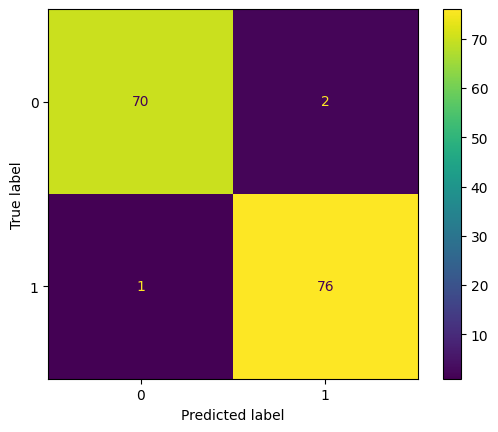

In [21]:
# Display the confusion matrix
disp.plot()

**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo ha sido registrado.

Ahora entiendes cómo construir y evaluar un modelo de regresión logística binomial con Python. En adelante, puedes comenzar a usar modelos de regresión logística binomial con tus propios conjuntos de datos.


## Graficos

## Curva ROI

La curva ROI (Return on Investment) es una herramienta gráfica que se utiliza para evaluar el desempeño y la rentabilidad de una inversión, proyecto o campaña. Muestra la relación entre la inversión realizada y el beneficio o retorno obtenido a lo largo del tiempo o en distintos escenarios.

En términos simples, la curva ROI ayuda a visualizar cuánto retorno (ganancia) se obtiene por cada unidad monetaria invertida, facilitando la toma de decisiones para optimizar inversiones y recursos.

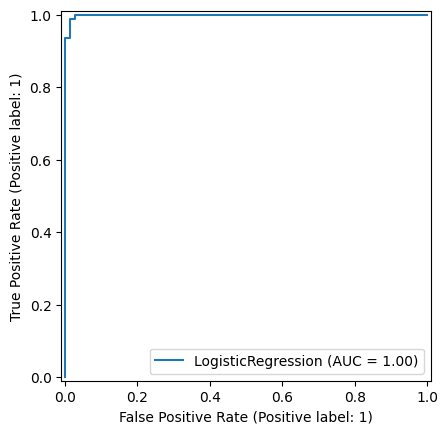

In [24]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(clf, X_test, y_test)

plt.show()

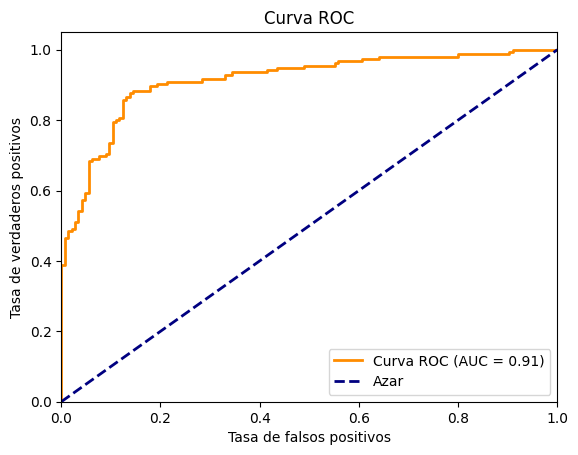

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Datos de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Obtener probabilidades predichas
y_scores = model.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()